In [36]:
import pandas as pd
import pymysql
import os
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

conn = pymysql.connect(
    host=os.environ.get('DB_HOST', 'localhost'),
    user=os.environ.get('DB_USER', 'root'),
    password=os.environ.get('DB_PASSWORD', 'root'),
    database='ads_db',
    charset='utf8mb4'
)
print("数据库连接成功")

数据库连接成功


In [37]:
df = pd.read_sql("""
    SELECT stat_date, workshop_name, capacity_achieved, qualified_rate
    FROM ads_produce_monitor
""", conn)
conn.close()

print(f"读取 {len(df)} 条数据")
print(f"车间数: {df['workshop_name'].nunique()}")
df.head()

C:\Users\q2898\AppData\Local\Temp\ipykernel_20688\661636443.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


读取 18004 条数据
车间数: 6


,stat_date,workshop_name,capacity_achieved,qualified_rate
0,2025-10-01,质检中心,83.41,96.13
1,2025-10-01,质检中心,67.69,98.86
2,2025-10-01,质检中心,78.40,97.01
3,2025-10-01,质检中心,62.97,91.33
4,2025-10-01,质检中心,75.30,92.42


In [38]:
ws = df.groupby('workshop_name')[['capacity_achieved', 'qualified_rate']].mean().round(2)
overall_cap = df['capacity_achieved'].mean()
overall_qual = df['qualified_rate'].mean()

print(f"整体产能达成率均值: {overall_cap:.2f}%")
print(f"整体良品率均值: {overall_qual:.2f}%")
print("\n各车间均值:")
ws_ala = ws.copy()
ws_ala.rename(columns={
    "workshop_name": "车间名称",
    "capacity_achieved": "产能达成率%",
    "qualified_rate": "良品率%",
}, inplace=True)
print(ws_ala.to_markdown(index=True, numalign="right", stralign="left"))

整体产能达成率均值: 80.05%
整体良品率均值: 92.37%

各车间均值:
| workshop_name   |   产能达成率% |   良品率% |
|:----------------|--------------:|----------:|
| 冲压车间        |         79.82 |     92.29 |
| 机加工车间      |         79.74 |     92.34 |
| 涂装车间        |         79.81 |     92.45 |
| 焊接车间        |         80.15 |     92.25 |
| 装配车间        |         80.32 |     92.44 |
| 质检中心        |         80.46 |     92.47 |


In [39]:
# 第 4 段：四象限分类（固定管理标准 80% / 95%）
# 判定规则：
#双优     : 产能达成率 ≥ 80% 且 良品率 ≥ 95%  → 标杆，保持并输出经验
#高产低质 : 产能达成率 ≥ 80% 但 良品率 < 95%  → 优先改善质量
#低产高质 : 产能达成率 < 80% 但 良品率 ≥ 95%  → 优先提升产能
#双低     : 产能达成率 < 80% 且 良品率 < 95%  → 产能与质量双线整改
CAP_STD, QUAL_STD = 80.0, 95.0


def classify_quadrant(row):
    cap_ok = row['capacity_achieved'] >= CAP_STD
    qual_ok = row['qualified_rate'] >= QUAL_STD
    if cap_ok and qual_ok:
        return '双优'
    if cap_ok and not qual_ok:
        return '高产低质'
    if not cap_ok and qual_ok:
        return '低产高质'
    return '双低'


n_before = len(ws)
ws = ws[['capacity_achieved', 'qualified_rate']]     .dropna(subset=['capacity_achieved', 'qualified_rate']).copy()
if len(ws) < n_before:
    print(f'⚠️ 提示：{n_before - len(ws)} 个车间因指标缺失被剔除')

# —— 距标准差距（百分点 pp，正数=达标，负数=缺口）——
ws['产能距标准'] = (ws['capacity_achieved'] - CAP_STD).round(2)
ws['良率距标准'] = (ws['qualified_rate'] - QUAL_STD).round(2)
# —— 缺口量（pp）与改善优先级（1=最紧急；只统计未达标方向）——
ws['产能缺口'] = ws['产能距标准'].clip(upper=0).abs()
ws['良率缺口'] = ws['良率距标准'].clip(upper=0).abs()
ws['缺口合计'] = (ws['产能缺口'] + ws['良率缺口']).round(2)
ws['象限'] = ws.apply(classify_quadrant, axis=1)
ws['改善优先级'] = ws['缺口合计'].rank(method='min', ascending=False).astype(int)
ws = ws.sort_values('改善优先级')
# 复制一份，不改动原始df
ws_show = ws.copy()

# 修改列名为中文
ws_show.rename(columns={
    "workshop_name": "车间名称",
    "capacity_achieved": "产能达成率%",
    "qualified_rate": "良品率%",
}, inplace=True)
print('四象限分类结果（改善优先级 1 = 最紧急）：')
# 再输出markdown（Markdown）表格
print(ws_show.to_markdown(index=True, numalign="right", stralign="left"))
print('\n各象限分布：')
for q in ['双优', '高产低质', '低产高质', '双低']:
    members = ws[ws['象限'] == q].index.tolist()
    if members:
        print(f'  {q}（{len(members)} 个）：{"、".join(members)}')
# —— 关键洞察（随数据自动生成）——
n_cap_low = int((ws['产能距标准'] < 0).sum())
n_qual_low = int((ws['良率距标准'] < 0).sum())
print('\n💡 关键洞察：')
if n_qual_low == len(ws):
    print(f'  ① 全部 {len(ws)} 个车间良品率均低于 {QUAL_STD:.0f}% 标准'
          f'（公司整体均值仅 {overall_qual:.2f}%），质量缺口是全局共性短板，'
          f'建议优先排查系统性质量根因（设备/工艺/物料）；')
elif n_qual_low > 0:
    print(f'  ① 有 {n_qual_low} 个车间良品率低于 {QUAL_STD:.0f}% 标准'
          f'（公司整体均值 {overall_qual:.2f}%）；')
else:
    print(f'  ① 全部车间良品率达标（≥ {QUAL_STD:.0f}%），质量水平稳定；')
if n_cap_low > 0:
    worst_cap = ws[ws['产能距标准'] < 0].sort_values('产能距标准').index[0]
    print(f'  ② 产能未达标车间 {n_cap_low} 个，距标准最远的是「{worst_cap}」'
          f'（缺口 {abs(ws.loc[worst_cap, "产能距标准"]):.2f}pp）；')
else:
    print(f'  ② 全部车间产能达成率达标（≥ {CAP_STD:.0f}%）；')
top1 = ws.sort_values('缺口合计', ascending=False).index[0]
print(f'  ③ 当前最需改善：「{top1}」（缺口合计 {ws.loc[top1, "缺口合计"]:.2f}pp'
      f'，其中产能 {ws.loc[top1, "产能缺口"]:.2f}pp、良率 {ws.loc[top1, "良率缺口"]:.2f}pp）。')


四象限分类结果（改善优先级 1 = 最紧急）：
| workshop_name   |   产能达成率% |   良品率% |   产能距标准 |   良率距标准 |   产能缺口 |   良率缺口 |   缺口合计 | 象限     |   改善优先级 |
|:----------------|--------------:|----------:|-------------:|-------------:|-----------:|-----------:|-----------:|:---------|-------------:|
| 机加工车间      |         79.74 |     92.34 |        -0.26 |        -2.66 |       0.26 |       2.66 |       2.92 | 双低     |            1 |
| 冲压车间        |         79.82 |     92.29 |        -0.18 |        -2.71 |       0.18 |       2.71 |       2.89 | 双低     |            2 |
| 焊接车间        |         80.15 |     92.25 |         0.15 |        -2.75 |          0 |       2.75 |       2.75 | 高产低质 |            3 |
| 涂装车间        |         79.81 |     92.45 |        -0.19 |        -2.55 |       0.19 |       2.55 |       2.74 | 双低     |            4 |
| 装配车间        |         80.32 |     92.44 |         0.32 |        -2.56 |          0 |       2.56 |       2.56 | 高产低质 |            5 |
| 质检中心        |         80.46 |     92.47 |    

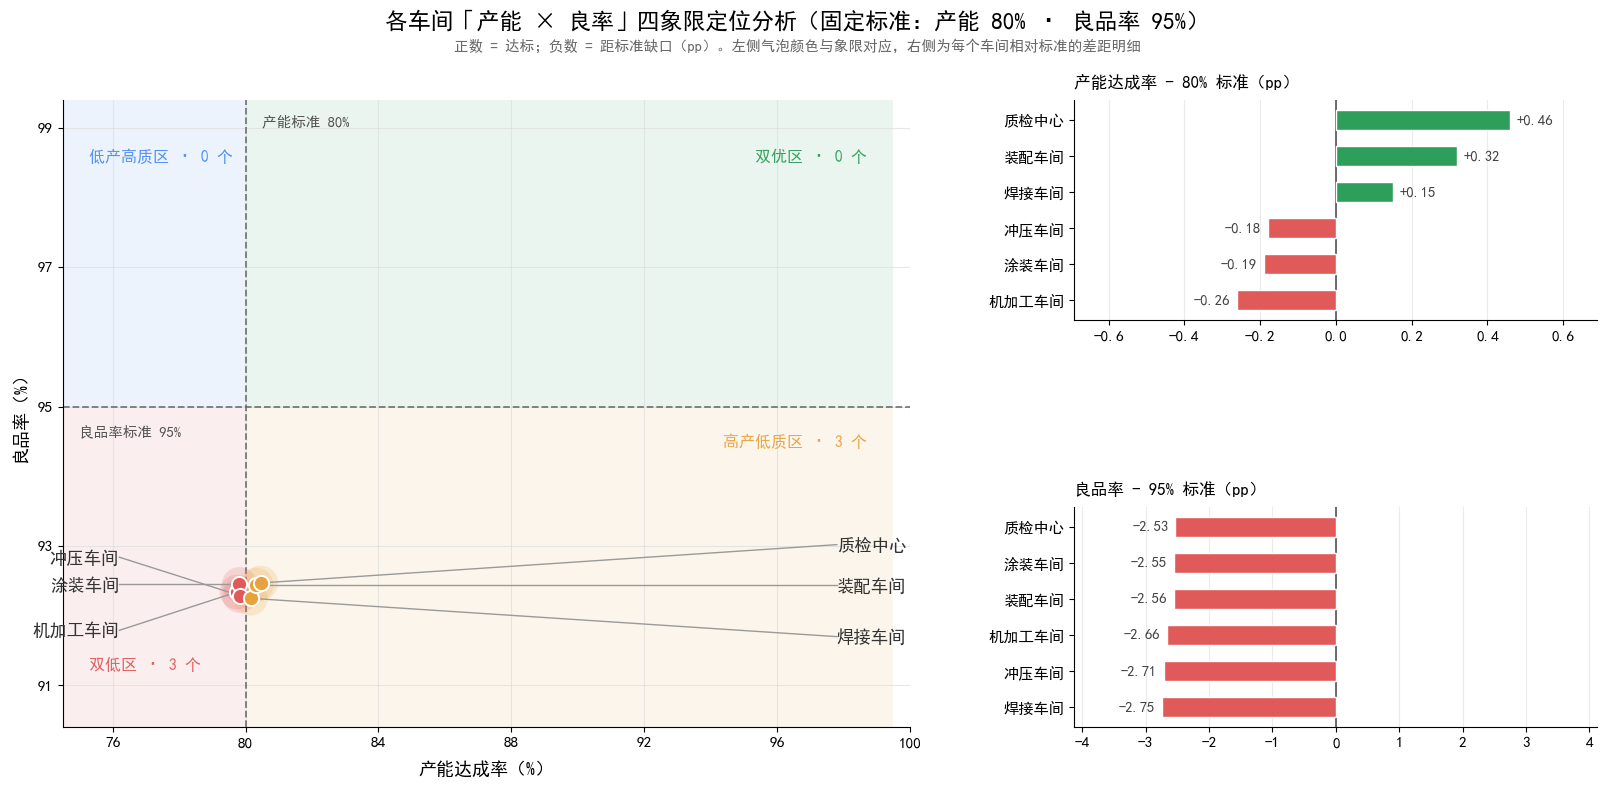

✅ 图表已保存：bi/analysis/capacity_quality_quadrant.png


In [40]:
# ============================================================
# 第 5 段：可视化 —— 四象限定位图 + 距标准缺口条形图
# ============================================================
import numpy as np
import matplotlib.patches as mpatches

CAP_STD, QUAL_STD = 80.0, 95.0
QCOLOR = {'双优': '#2E9E5B', '高产低质': '#E8A23D',
          '低产高质': '#4C8BF5', '双低': '#E05A5A'}
QCN = {'双优': '双优', '高产低质': '高产低质',
       '低产高质': '低产高质', '双低': '双低'}

pts = ws.rename_axis('workshop_name').reset_index()     .sort_values('capacity_achieved').reset_index(drop=True)
counts = ws['象限'].value_counts()

# ================= 画布与四象限主图 =================
xmin, xmax, ymin, ymax = 74.5, 99.5, 90.4, 99.4

fig = plt.figure(figsize=(16.5, 8.2))
gs = fig.add_gridspec(2, 2, width_ratios=[1.62, 1.0], height_ratios=[1.0, 1.0],
                      left=0.055, right=0.985, top=0.875, bottom=0.11,
                      wspace=0.24, hspace=0.85)
ax1 = fig.add_subplot(gs[:, 0])   # 四象限主图
ax2 = fig.add_subplot(gs[0, 1])   # 产能距标准
ax3 = fig.add_subplot(gs[1, 1])   # 良率距标准

# 四个象限的淡色底衬
for (x0, x1, y0, y1), q in [
    ((CAP_STD, xmax, QUAL_STD, ymax), '双优'),
    ((CAP_STD, xmax, ymin, QUAL_STD), '高产低质'),
    ((xmin, CAP_STD, QUAL_STD, ymax), '低产高质'),
    ((xmin, CAP_STD, ymin, QUAL_STD), '双低'),
]:
    ax1.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                     facecolor=QCOLOR[q], alpha=0.10,
                                     edgecolor='none', zorder=0))

ax1.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)
ax1.set_xticks([76, 80, 84, 88, 92, 96, 100])
ax1.set_yticks([91, 93, 95, 97, 99])
ax1.grid(True, color='#DDDDDD', linewidth=0.8, alpha=0.7)
ax1.set_axisbelow(True)
for sp in ('top', 'right'):
    ax1.spines[sp].set_visible(False)

# 管理标准参考线 + 标注
ax1.axvline(CAP_STD, color='#6B6B6B', linestyle='--', linewidth=1.3, alpha=0.9, zorder=1)
ax1.axhline(QUAL_STD, color='#6B6B6B', linestyle='--', linewidth=1.3, alpha=0.9, zorder=1)
ax1.text(CAP_STD + 0.5, ymax - 0.3, '产能标准 80%', fontsize=10.5,
         color='#555555', va='center', zorder=2)
ax1.text(xmin + 0.5, QUAL_STD - 0.35, '良品率标准 95%', fontsize=10.5,
         color='#555555', va='center', zorder=2)

# 象限名 + 数量（放在各象限远离数据簇的角落）
zone_pos = {
    '双优':    (xmax - 0.8, ymax - 0.8),
    '低产高质': (xmin + 0.8, ymax - 0.8),
    '高产低质': (xmax - 0.8, 94.5),
    '双低':    (xmin + 0.8, 91.3),
}
zone_ha = {'双优': 'right', '低产高质': 'left',
           '高产低质': 'right', '双低': 'left'}
for q, (zx, zy) in zone_pos.items():
    n = int(counts.get(q, 0))
    ax1.text(zx, zy, f'{QCN[q]}区 · {n} 个', fontsize=11.5, color=QCOLOR[q],
             fontweight='bold', ha=zone_ha[q], va='center', alpha=0.95, zorder=2)

# 散点：外层淡色光环（体现区域聚类）+ 内层实心核（区分个体）
for _, r in pts.iterrows():
    ax1.scatter(r['capacity_achieved'], r['qualified_rate'], s=620,
                color=QCOLOR[r['象限']], alpha=0.18, edgecolor='none', zorder=3)
for _, r in pts.iterrows():
    ax1.scatter(r['capacity_achieved'], r['qualified_rate'], s=120,
                color=QCOLOR[r['象限']], edgecolor='white', linewidth=1.4,
                zorder=4, alpha=1.0)

# 车间名：向左/右扇形展开并用细线引回数据点，避免相互压盖
def fan_labels(group, side_x, ha):
    m = len(group)
    if m == 0:
        return
    offs = np.linspace(-(m - 1) / 2, (m - 1) / 2, m) * 0.55 if m > 1 else [0.0]
    for (_, r), dy in zip(group.iterrows(), offs):
        ly = r['qualified_rate'] + dy
        ax1.plot([r['capacity_achieved'], side_x], [r['qualified_rate'], ly],
                 color='#9A9A9A', linewidth=1.0, zorder=3)
        ax1.text(side_x, ly, r['workshop_name'], fontsize=12.5, color='#333333',
                 ha=ha, va='center', zorder=5, fontweight='bold')

fan_labels(pts[pts['capacity_achieved'] < CAP_STD], xmin + 1.7, 'right')
fan_labels(pts[pts['capacity_achieved'] >= CAP_STD], xmax - 1.7, 'left')

ax1.set_xlabel('产能达成率（%）', fontsize=13, labelpad=8)
ax1.set_ylabel('良品率（%）', fontsize=13, labelpad=8)
ax1.tick_params(labelsize=11)

# ================= 右侧：距标准缺口（pp） =================
def gap_panel(ax, sort_col, title, good_color, bad_color):
    d = pts.sort_values(sort_col, ascending=True)
    vals = d[sort_col].values
    ax.barh(d['workshop_name'], vals, color=[good_color if v >= 0 else bad_color
                                             for v in vals],
            edgecolor='white', height=0.55, zorder=3)
    ax.axvline(0, color='#444444', linewidth=1.1, zorder=2)
    ax.set_title(title, fontsize=12, loc='left', pad=9)
    ax.grid(axis='x', color='#E3E3E3', linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=11)
    lim = max(abs(vals).max() * 1.5, 0.25)
    ax.set_xlim(-lim, lim)
    for b, v in zip(ax.patches, vals):
        ax.annotate(f'{v:+.2f}', xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                    xytext=(5 if v >= 0 else -5, 0), textcoords='offset points',
                    ha='left' if v >= 0 else 'right', va='center',
                    fontsize=10.5, color='#444444')

gap_panel(ax2, '产能距标准', '产能达成率 - 80% 标准（pp）', '#2E9E5B', '#E05A5A')
gap_panel(ax3, '良率距标准', '良品率 - 95% 标准（pp）', '#2E9E5B', '#E05A5A')

fig.suptitle('各车间「产能 × 良率」四象限定位分析（固定标准：产能 80% · 良品率 95%）',
             fontsize=16.5, fontweight='bold', y=0.985)
fig.text(0.5, 0.935, '正数 = 达标；负数 = 距标准缺口（pp）。左侧气泡颜色与象限对应，'
                     '右侧为每个车间相对标准的差距明细',
         ha='center', fontsize=10.5, color='#666666')

plt.savefig('bi/analysis/capacity_quality_quadrant.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ 图表已保存：bi/analysis/capacity_quality_quadrant.png')


In [41]:
print("\n" + "="*60)
print("📋 改进建议")
print("="*60)

for idx, row in ws.iterrows():
    if row['象限'] == '⚡ 高产低质':
        print(f"🔧 {idx}: 产能达标但良率偏低 → 建议排查质量问题")
    elif row['象限'] == '🛡️ 低产高质':
        print(f"📈 {idx}: 良率高但产能不足 → 建议提升产能")
    elif row['象限'] == '⚠️ 双低':
        print(f"🚨 {idx}: 产能和良率均需改进 → 建议全面排查")
    else:
        print(f"✅ {idx}: 产能和良率均达标，保持当前水平")


📋 改进建议
✅ 机加工车间: 产能和良率均达标，保持当前水平
✅ 冲压车间: 产能和良率均达标，保持当前水平
✅ 焊接车间: 产能和良率均达标，保持当前水平
✅ 涂装车间: 产能和良率均达标，保持当前水平
✅ 装配车间: 产能和良率均达标，保持当前水平
✅ 质检中心: 产能和良率均达标，保持当前水平
